## 1. Business Understanding.

## 2. Data Collection

In [123]:
!pip install lightgbm


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [124]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,precision_score
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

In [134]:
credit_card_data = pd.read_csv(filepath_or_buffer = "credit_card_clean.csv")
credit_card_data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,female,university,married,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,female,university,single,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,female,university,single,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,female,university,married,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,male,university,married,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,male,highschool,married,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,male,highschool,single,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,male,university,single,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,male,highschool,married,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


## 3. Data Understanding.

In [135]:
credit_card_data.isna().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_1        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

In [136]:
credit_card_data.shape

(30000, 25)

In [137]:
credit_card_data.dtypes

ID             int64
LIMIT_BAL    float64
SEX           object
EDUCATION     object
MARRIAGE      object
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

## 4. Data Preparation.

In [138]:
credit_card_data.head(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,female,university,married,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,female,university,single,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,female,university,single,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,female,university,married,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,male,university,married,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [139]:
del credit_card_data["ID"]

In [140]:
credit_card_data

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,female,university,married,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,female,university,single,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,female,university,single,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,female,university,married,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,male,university,married,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,male,highschool,married,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,male,highschool,single,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,male,university,single,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,male,highschool,married,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [141]:
le = LabelEncoder()
credit_card_data["SEX"] = le.fit_transform(credit_card_data ["SEX"])
credit_card_data["EDUCATION"] = le.fit_transform(credit_card_data ["EDUCATION"])
credit_card_data["MARRIAGE"] = le.fit_transform(credit_card_data ["MARRIAGE"])
credit_card_data

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,0,3,0,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,0,3,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,0,3,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,0,3,0,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,3,0,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,1,0,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,1,1,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,1,3,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,1,1,0,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [142]:
credit_card_data.dtypes

LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE       int64
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

## 5. Model Building.

In [143]:
X = credit_card_data.drop(labels = "DEFAULT",axis=1)
y = credit_card_data["DEFAULT"]

In [144]:
X.shape,y.shape

((30000, 23), (30000,))

In [64]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=123,shuffle=True,stratify=y,)

In [145]:
X_train.shape,y_train.shape

((24000, 23), (24000,))

In [146]:
X_test.shape,y_test.shape

((6000, 23), (6000,))

## 6. Model Training

#### Training time Analysis.

In [147]:
abd_classifier  = AdaBoostClassifier()
gbc_classifier  = GradientBoostingClassifier(n_estimators=150)
xgb_classifier  = XGBClassifier(n_estimators=150)
lgbm_Classifier = LGBMClassifier(n_estimator=150)

In [148]:
%%time
abd_classifier.fit(X_train,y_train)

CPU times: total: 5.14 s
Wall time: 5.6 s


,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [149]:
%%time
gbc_classifier.fit(X_train,y_train)

CPU times: total: 47.6 s
Wall time: 49.4 s


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,150
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [150]:
%%time
xgb_classifier.fit(X_train,y_train)

CPU times: total: 6.25 s
Wall time: 1.07 s


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [151]:
%%time
lgbm_Classifier.fit(X_train,y_train)

[LightGBM] [Warning] Unknown parameter: n_estimator
[LightGBM] [Warning] Unknown parameter: n_estimator
[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011405 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3259
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639
CPU times: total: 5.58 s
Wall time: 827 ms


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Model Test

In [152]:
y_pred_adb  = adb_classifier.predict(X_test)
y_pred_gbc  = gbc_classifier.predict(X_test)
y_pred_xgb  = xgb_classifier.predict(X_test)
y_pred_lgbm = lgbm_Classifier.predict(X_test)

[LightGBM] [Warning] Unknown parameter: n_estimator


## 8. Model Evaluation

#### AdaBoost Evaluvation

In [153]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_adb),4))
print("Precision Score:",round(precision_score(y_test,y_pred_adb),4))
print("Recall Score:",round(recall_score(y_test,y_pred_adb),4))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_adb))

Accuracy Score: 0.8218
Precision Score: 0.7048
Recall Score: 0.3346
Confusion Matrix:
 [[4487  186]
 [ 883  444]]


#### Gradient Boosting Evaluvation

In [154]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_gbc),4))
print("Precision Score:",round(precision_score(y_test,y_pred_gbc),4))
print("Recall Score:",round(recall_score(y_test,y_pred_gbc),4))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_gbc))

Accuracy Score: 0.8235
Precision Score: 0.6914
Recall Score: 0.3647
Confusion Matrix:
 [[4457  216]
 [ 843  484]]


#### XGBM Evaluvation

In [155]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_xgb),4))
print("Precision Score:",round(precision_score(y_test,y_pred_xgb),4))
print("Recall Score:",round(recall_score(y_test,y_pred_xgb),4))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_xgb))

Accuracy Score: 0.8122
Precision Score: 0.6344
Recall Score: 0.3557
Confusion Matrix:
 [[4401  272]
 [ 855  472]]


#### Light Gradient Boosting Evaluation.

In [156]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_lgbm),4))
print("Precision Score:",round(precision_score(y_test,y_pred_lgbm),4))
print("Recall Score:",round(recall_score(y_test,y_pred_lgbm),4))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_lgbm))

Accuracy Score: 0.825
Precision Score: 0.6981
Recall Score: 0.3677
Confusion Matrix:
 [[4462  211]
 [ 839  488]]


## Let's Learn Feature Important.

In [160]:
adb_feature_imp  = adb_classifier.feature_importances_
gbc_feature_imp  = gbc_classifier.feature_importances_
xgb_feature_imp  = xgb_classifier.feature_importances_
lgbm_feature_imp = lgbm_Classifier.feature_importances_

In [170]:
Feature_Important_List= pd.DataFrame(data={"Features":X.columns,
                                           "AdaBoosting_Features":adb_feature_imp,
                                           "GradientBoosting_Features":gbc_feature_imp,
                                           "XGBM_Features":xgb_feature_imp,
                                           "LGBM_Features":lgbm_feature_imp})
Feature_Important_List                   

,Features,AdaBoosting_Features,GradientBoosting_Features,XGBM_Features,LGBM_Features
0,LIMIT_BAL,0.057269,0.031976,0.024192,236
1,SEX,0.000000,0.002554,0.017875,40
2,EDUCATION,0.000000,0.004100,0.021649,72
3,MARRIAGE,0.017747,0.003423,0.019403,35
4,AGE,0.000000,0.009658,0.019908,217
5,PAY_1,0.513985,0.592774,0.367021,98
6,PAY_2,0.035080,0.085198,0.101706,44
7,PAY_3,0.052493,0.039475,0.047288,52
8,PAY_4,0.004686,0.015900,0.036657,36
9,PAY_5,0.017710,0.012994,0.037529,38


##### Question -1 Display The Top 10 features Of AdaBoost

In [171]:
import seaborn as sns

In [183]:
AdaBoost_Top_Features = Feature_Important_List.sort_values(by = "AdaBoosting_Features",ascending = False)
AdaBoost_Top_Features.head(10)

,Features,AdaBoosting_Features,GradientBoosting_Features,XGBM_Features,LGBM_Features
5,PAY_1,0.513985,0.592774,0.367021,98
17,PAY_AMT1,0.087824,0.023866,0.023524,170
18,PAY_AMT2,0.064727,0.023151,0.022738,205
0,LIMIT_BAL,0.057269,0.031976,0.024192,236
7,PAY_3,0.052493,0.039475,0.047288,52
10,PAY_6,0.042327,0.017496,0.038849,50
19,PAY_AMT3,0.037968,0.022786,0.026447,177
6,PAY_2,0.035080,0.085198,0.101706,44
20,PAY_AMT4,0.019563,0.012384,0.022295,157
15,BILL_AMT5,0.018466,0.007887,0.020669,142


<Axes: xlabel='AdaBoosting_Features', ylabel='Features'>

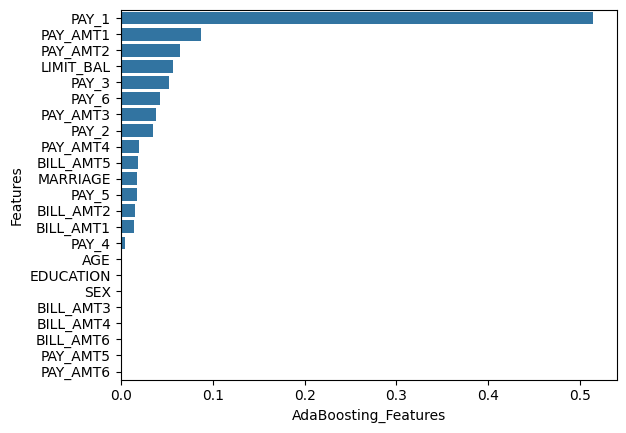

In [181]:
sns.barplot(data=AdaBoost_Top_Features,x="AdaBoosting_Features",y="Features",)

In [184]:
GradientBoost_Top_Features = Feature_Important_List.sort_values(by = "GradientBoosting_Features",ascending = False)
GradientBoost_Top_Features.head(10)

,Features,AdaBoosting_Features,GradientBoosting_Features,XGBM_Features,LGBM_Features
5,PAY_1,0.513985,0.592774,0.367021,98
6,PAY_2,0.035080,0.085198,0.101706,44
7,PAY_3,0.052493,0.039475,0.047288,52
11,BILL_AMT1,0.014796,0.033004,0.024778,213
0,LIMIT_BAL,0.057269,0.031976,0.024192,236
17,PAY_AMT1,0.087824,0.023866,0.023524,170
18,PAY_AMT2,0.064727,0.023151,0.022738,205
19,PAY_AMT3,0.037968,0.022786,0.026447,177
10,PAY_6,0.042327,0.017496,0.038849,50
8,PAY_4,0.004686,0.015900,0.036657,36


<Axes: xlabel='GradientBoosting_Features', ylabel='Features'>

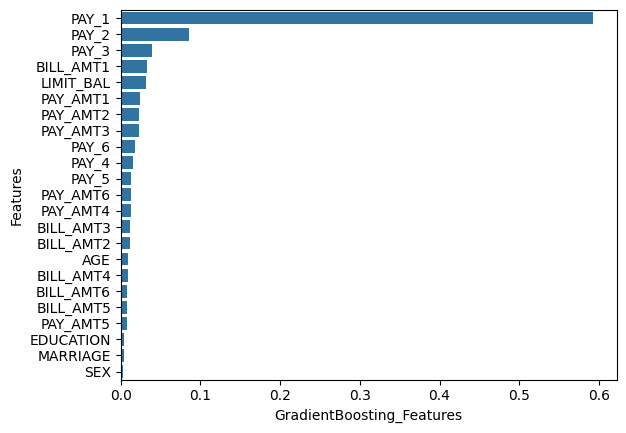

In [186]:
sns.barplot(data=GradientBoost_Top_Features,x="GradientBoosting_Features",y="Features",)

## THE END!!!